In [1]:
import numpy as np # Numerical computing library for array operations
import pandas as pd # Data manipulation library for handling tabular data
import matplotlib.pyplot as plt # Plotting library for data visualization
import yfinance as yf # Yahoo Finance API for data retrieval

print("Numpy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)
print("YFinance version:", yf.__version__)
print("Setup working.")

Numpy version: 2.4.6
Pandas version: 2.2.3
Matplotlib version: 3.10.9
YFinance version: 1.4.1
Setup working.


In [2]:
ticker = "AAPL" #Apple Inc. stock ticker symbol

data = yf.download(
    ticker, 
    start="2010-01-01", 
    end="2024-12-31", 
    auto_adjust=False # Adjust historical data for corporate actions (e.g., dividends, stock splits)
    ) # Download historical stock data for Apple Inc. from Yahoo Finance

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2010-01-04,6.406481,7.643214,7.660714,7.585000,7.622500,493729600
2010-01-05,6.417557,7.656429,7.699643,7.616071,7.664286,601904800
2010-01-06,6.315478,7.534643,7.686786,7.526786,7.656429,552160000
2010-01-07,6.303801,7.520714,7.571429,7.466071,7.562500,477131200
2010-01-08,6.345710,7.570714,7.571429,7.466429,7.510714,447610800


In [3]:
data["log_return"] = np.log(data["Close"] / data["Close"].shift(1)) # Calculate the logarithmic returns of the closing prices and store them in a new column called "log_return"
data = data.dropna() # Remove any rows with missing values (NaN) that may have been introduced by the shift operation when calculating log returns

data[["Close", "log_return"]].head() # Display the first few rows of the DataFrame, showing only the "Close" and "log_return" columns to verify that the log returns have been calculated correctly.

Price,Close,log_return
Ticker,AAPL,
Date,,
2010-01-05,7.656429,0.001727
2010-01-06,7.534643,-0.016034
2010-01-07,7.520714,-0.001850
2010-01-08,7.570714,0.006626
2010-01-11,7.503929,-0.008861


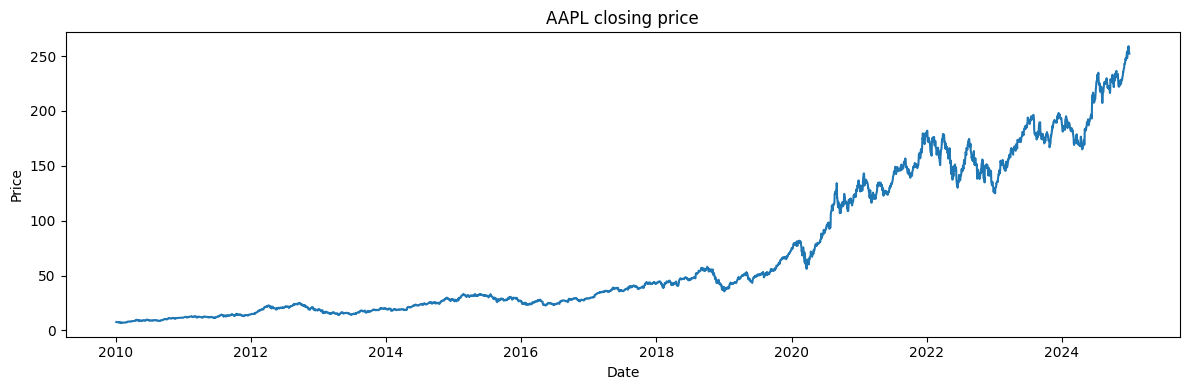

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data["Close"])
plt.title("AAPL closing price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

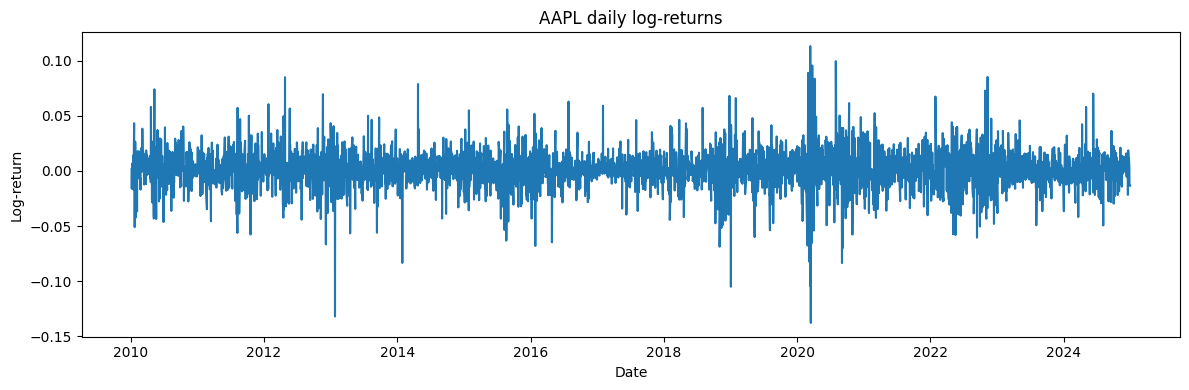

In [5]:
plt.figure(figsize=(12, 4))
plt.plot(data.index, data["log_return"])
plt.title("AAPL daily log-returns")
plt.xlabel("Date")
plt.ylabel("Log-return")
plt.tight_layout()
plt.show()